In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip -q install bertopic sentence-transformers umap-learn hdbscan==0.8.33 scikit-learn


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

In [4]:
#  Load your clean dataset

save_path_csv = "/content/drive/MyDrive/nlp/final project/clean_base_dataset.csv"
df = pd.read_csv(save_path_csv)

print("Loaded:", save_path_csv)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())


Loaded: /content/drive/MyDrive/nlp/final project/clean_base_dataset.csv
Shape: (196276, 6)
Columns: ['url', 'date', 'title', 'clean_text', 'text_len', 'domain']


,url,date,title,clean_text,text_len,domain
0,https://blockworks.co/price/bad,2025-06-23,"Bad Idea AI Price (BAD), Market Cap, Price Tod...","Bad Idea AI Price (BAD), Market Cap, Price Tod...",3501,blockworks.co
1,https://boingboing.net/2024/07/01/this-ai-vide...,2024-07-01,This AI video of gymnastics might be the freak...,This AI video of gymnastics might be the freak...,5585,boingboing.net
2,https://boingboing.net/2024/09/18/if-using-ai-...,2024-09-22,"If using AI feels like a chore, try this - Boi...","If using AI feels like a chore, try this - Boi...",5880,boingboing.net
3,https://citylife.capetown/gl/uncategorized/the...,2023-11-10,The Road Ahead: How China's AI Foundation Mode...,The Road Ahead: How China's AI Foundation Mode...,4072,citylife.capetown
4,https://citylife.capetown/kk/uncategorized/mic...,2023-11-19,Microsoft and Nvidia to Empower Developers wit...,Microsoft and Nvidia to Empower Developers wit...,4347,citylife.capetown


In [5]:
df = df[df["clean_text"].fillna("").str.len() >= 200].copy()
df["clean_text"] = df["clean_text"].fillna("").astype(str)
print("After dropping short docs:", df.shape)

# Light cleaning (BERTopic-friendly)
#    - remove urls/emails
#    - normalize whitespace
#    - keep text mostly natural (NO lemmatization needed)
def light_clean_for_bertopic(text: str) -> str:
    text = str(text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_bt"] = df["clean_text"].apply(light_clean_for_bertopic)


After dropping short docs: (196276, 6)


In [6]:
SAMPLE_N = 25000
RANDOM_STATE = 42
MAX_CHARS = 2000
MIN_CHARS = 200   # drop extremely short docs


df_clean = df.copy()
df_clean["text_bt"] = df_clean["text_bt"].astype(str)
df_clean = df_clean[df_clean["text_bt"].str.len() > MIN_CHARS].copy()

print("Docs after length filter:", len(df_clean))

df_model = df_clean.sample(
    n=min(SAMPLE_N, len(df_clean)),
    random_state=RANDOM_STATE
).copy()

documents = [
    text[:MAX_CHARS]
    for text in df_model["text_bt"].tolist()
]

print("Sample size:", len(documents))
print("Average length:", int(np.mean([len(t) for t in documents])))
print("Max length:", max(len(t) for t in documents))
print("Example snippet:\n", documents[0][:250])

Docs after length filter: 196276
Sample size: 25000
Average length: 1944
Max length: 2000
Example snippet:
 Wendy's adding Google Cloud AI tech to drive-thru ordering as part of test LiveNewsWeatherGood Day OrlandoWe Love FloridaContests More Watch Live Expand / Collapse search ☰ Search site News Florida HeadlinesCentral Florida HeadlinesNational Headlines


In [7]:
#Build BERTopic components (balanced defaults)

# Embeddings (fast + strong baseline)
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# UMAP (reduces dimensionality for clustering)
umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=RANDOM_STATE
)

#  HDBSCAN (discovers number of clusters automatically)
# If you get too many outliers, reduce min_samples or min_cluster_size
hdbscan_model = HDBSCAN(
    min_cluster_size=30,          # try 25/30/40 for your data size
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
# 3.4 Vectorizer + c-TF-IDF topic representation
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=10,                    # higher for big corpora -> less noise
    ngram_range=(1, 2)
)

ctfidf_model = ClassTfidfTransformer(
    reduce_frequent_words=True
)

# 3.5 Create model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    calculate_probabilities=False,   # faster; turn True only if you need probs
    verbose=True
)

In [9]:
# 4) Fit BERTopic on the sample
topics, probs = topic_model.fit_transform(documents)

topic_info = topic_model.get_topic_info()
display(topic_info.head(15))

n_topics = (topic_info["Topic"] != -1).sum()
outlier_frac = (np.array(topics) == -1).mean()
print(f"Topics (excl -1): {n_topics}")
print(f"Outlier fraction: {outlier_frac:.2%}")


#  Build a "topic evidence" table
#    - top words
#    - representative docs (fallback: top docs by c-TF-IDF similarity is built-in)

rep_docs = topic_model.get_representative_docs()  # dict: topic_id -> list[str]

rows = []
for _, r in topic_info.iterrows():
    tid = int(r["Topic"])
    if tid == -1:
        continue

    top_words = [w for w, _ in (topic_model.get_topic(tid) or [])[:12]]
    reps = rep_docs.get(tid, [])
    reps = [x[:300].replace("\n", " ") + "..." for x in reps[:3]]

    rows.append({
        "topic_id": tid,
        "count": int(r["Count"]),
        "top_words": ", ".join(top_words),
        "proposed_label": "",        # fill manually
        "rep_snippets": " | ".join(reps)
    })

bertopic_table = pd.DataFrame(rows).sort_values("count", ascending=False)
display(bertopic_table.head(20))



2026-02-23 21:33:51,361 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

2026-02-23 22:27:46,721 - BERTopic - Embedding - Completed ✓
2026-02-23 22:27:46,733 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-23 22:28:50,243 - BERTopic - Dimensionality - Completed ✓
2026-02-23 22:28:50,246 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-23 22:28:58,901 - BERTopic - Cluster - Completed ✓
2026-02-23 22:28:58,919 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-23 22:29:16,425 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8461,-1_opens new_opens_new window_window,"[opens new, opens, new window, window, traded,...",[Elon Musk says he’ll create ‘TruthGPT’ to cou...
1,0,1495,0_prnewswire_country music_2023 prnewswire_dc,"[prnewswire, country music, 2023 prnewswire, d...",[SAP and Google Cloud Enhance Open Data Cloud ...
2,1,626,1_donate_programs_air playing_npr,"[donate, programs, air playing, npr, 00 00, sc...",[Yuval Noah Harari warns AI may mean the end o...
3,2,517,2_entertain ment_ment_transportation_entertain,"[entertain ment, ment, transportation, enterta...",[planetRE Announces AI Intellectual Assistant ...
4,3,508,3_gpt_chatgpt_chatbot_openai,"[gpt, chatgpt, chatbot, openai, users, chatbot...",[5 simple ChatGPT cheat codes to help you get ...
5,4,460,4_cancer_disease_channels_drug,"[cancer, disease, channels, drug, fierce, medi...",[MCRA Announces Launch of Integrated AI & Imag...
6,5,400,5_republic_congo_presswire_ein presswire,"[republic, congo, presswire, ein presswire, is...",[Stem Tronics Launches the First Artificial In...
7,6,390,6_oil energy_europe arab_asia africa_mena,"[oil energy, europe arab, asia africa, mena, a...",[Ecomanager AI Joins Fastercapital's Raise Cap...
8,7,278,7_india_minister_indian_india ai,"[india, minister, indian, india ai, modi, delh...",[India and EU Forge Deeper Ties in AI and Digi...
9,8,275,8_outdoors_rawpixel_px 300_jpeg,"[outdoors, rawpixel, px 300, jpeg, px, 300, im...",[Firework fireworks outdoors night. AI | Premi...


Topics (excl -1): 161
Outlier fraction: 33.84%


,topic_id,count,top_words,proposed_label,rep_snippets
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc...",,SAP and Google Cloud Enhance Open Data Cloud W...
1,1,626,"donate, programs, air playing, npr, 00 00, sch...",,Yuval Noah Harari warns AI may mean the end of...
2,2,517,"entertain ment, ment, transportation, entertai...",,planetRE Announces AI Intellectual Assistant w...
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots...",,5 simple ChatGPT cheat codes to help you get b...
4,4,460,"cancer, disease, channels, drug, fierce, medic...",,MCRA Announces Launch of Integrated AI & Imagi...
5,5,400,"republic, congo, presswire, ein presswire, isl...",,Stem Tronics Launches the First Artificial Int...
6,6,390,"oil energy, europe arab, asia africa, mena, ar...",,Ecomanager AI Joins Fastercapital's Raise Capi...
7,7,278,"india, minister, indian, india ai, modi, delhi...",,India and EU Forge Deeper Ties in AI and Digit...
8,8,275,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",,Firework fireworks outdoors night. AI | Premiu...
9,9,275,"galaxy, samsung, pixel, s24, samsung galaxy, g...",,Google Workspace gets new generative AI featur...


In [11]:
model_path = "/content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl"
topic_model.save(model_path)

print("Saved BERTopic model to:", model_path)

2026-02-23 22:30:57,816 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved BERTopic model to: /content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl


In [13]:
model_path = "/content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl"
topic_model.save(model_path)

print("Saved BERTopic model to:", model_path)

2026-02-23 22:32:51,963 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Saved BERTopic model to: /content/drive/MyDrive/nlp/final project/bertopic_model_sample.pkl


In [14]:
bertopic_table.head(20)

,topic_id,count,top_words,proposed_label,rep_snippets
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc...",,SAP and Google Cloud Enhance Open Data Cloud W...
1,1,626,"donate, programs, air playing, npr, 00 00, sch...",,Yuval Noah Harari warns AI may mean the end of...
2,2,517,"entertain ment, ment, transportation, entertai...",,planetRE Announces AI Intellectual Assistant w...
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots...",,5 simple ChatGPT cheat codes to help you get b...
4,4,460,"cancer, disease, channels, drug, fierce, medic...",,MCRA Announces Launch of Integrated AI & Imagi...
5,5,400,"republic, congo, presswire, ein presswire, isl...",,Stem Tronics Launches the First Artificial Int...
6,6,390,"oil energy, europe arab, asia africa, mena, ar...",,Ecomanager AI Joins Fastercapital's Raise Capi...
7,7,278,"india, minister, indian, india ai, modi, delhi...",,India and EU Forge Deeper Ties in AI and Digit...
8,8,275,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",,Firework fireworks outdoors night. AI | Premiu...
9,9,275,"galaxy, samsung, pixel, s24, samsung galaxy, g...",,Google Workspace gets new generative AI featur...


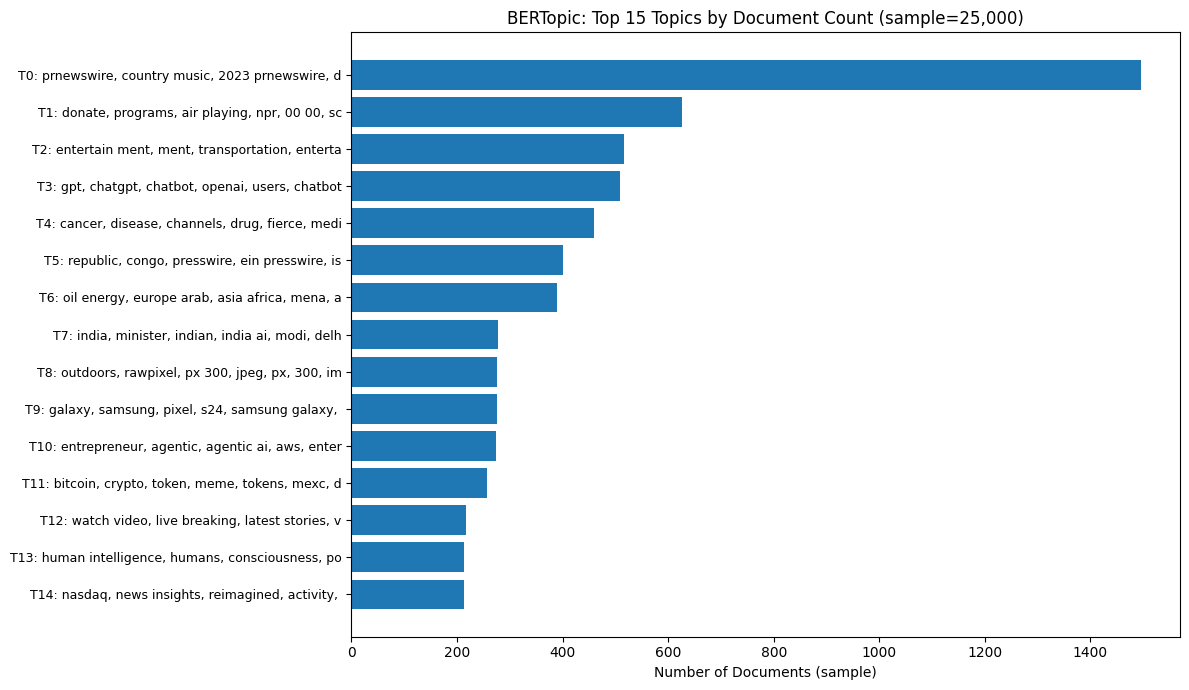

In [15]:
#  Visual for slides: Top topics by size (sample)
topK = 15
plot_df = bertopic_table.head(topK).copy()

plt.figure(figsize=(12, 7))
plt.barh(range(len(plot_df)), plot_df["count"])
plt.yticks(range(len(plot_df)),
           [f"T{tid}: {lab[:45]}" for tid, lab in zip(plot_df["topic_id"], plot_df["top_words"])],
           fontsize=9)
plt.gca().invert_yaxis()
plt.xlabel("Number of Documents (sample)")
plt.title(f"BERTopic: Top {topK} Topics by Document Count (sample={SAMPLE_N:,})")
plt.tight_layout()
plt.show()


In [16]:
#  Apply topic assignments back to your df_model
df_model["topic_id"] = topics

# topic share (excluding outliers)
topic_counts = df_model[df_model["topic_id"] != -1]["topic_id"].value_counts()
topic_share = (topic_counts / (df_model["topic_id"] != -1).sum()).sort_values(ascending=False)

topic_share_df = topic_share.reset_index()
topic_share_df.columns = ["topic_id", "doc_share"]
display(topic_share_df.head(15))

,topic_id,doc_share
0,0,0.090392
1,1,0.037850
2,2,0.031259
3,3,0.030715
4,4,0.027813
5,5,0.024185
6,6,0.023581
7,7,0.016809
8,9,0.016627
9,8,0.016627


In [17]:
# 9) Company extraction (fast baseline): ORGs from TITLES
import spacy
from collections import Counter

nlp_ner = spacy.load("en_core_web_sm")

def extract_orgs(text):
    doc = nlp_ner(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

df_model["orgs"] = df_model["title"].apply(extract_orgs)

rows = []
for tid in sorted(df_model["topic_id"].unique()):
    if tid == -1:
        continue

    orgs = [
        org
        for org_list in df_model[df_model["topic_id"] == tid]["orgs"]
        for org in org_list
    ]
    for org, cnt in Counter(orgs).most_common(10):
        rows.append({"topic_id": tid, "company": org, "mention_count": cnt})

company_table = pd.DataFrame(rows).sort_values(["topic_id", "mention_count"], ascending=[True, False])
display(company_table.head(30))


,topic_id,company,mention_count
0,0,AI,39
1,0,IBM,13
2,0,Deloitte,13
3,0,Technology Opportunities Fund Discloses Source...,10
4,0,AI &amp,10
5,0,Virtus Artificial Intelligence &,9
6,0,World,7
7,0,Artificial Intelligence,7
8,0,Bain &amp,7
9,0,SAS,7


In [19]:
import numpy as np
import pandas as pd
from collections import Counter
import spacy

topic_info = topic_model.get_topic_info()  # has Topic, Count, Name, etc.
rep_docs = topic_model.get_representative_docs()  # dict: topic_id -> list[str]

rows = []
N = len(documents)

for _, r in topic_info.iterrows():
    tid = int(r["Topic"])
    cnt = int(r["Count"])
    if tid == -1:
        continue  # outliers/noise

    words = topic_model.get_topic(tid) or []
    top_words = [w for w, _ in words[:12]]

    reps = rep_docs.get(tid, [])
    reps = [str(x)[:260].replace("\n", " ") + "..." for x in reps[:3]]

    rows.append({
        "topic_id": tid,
        "doc_count": cnt,
        "doc_share": cnt / N,
        "top_words": ", ".join(top_words),
        "rep_snippets": " | ".join(reps)
    })

bertopic_table = (
    pd.DataFrame(rows)
    .sort_values("doc_count", ascending=False)
    .reset_index(drop=True)
)

display(bertopic_table.head(20))

,topic_id,doc_count,doc_share,top_words,rep_snippets
0,0,1495,0.05980,"prnewswire, country music, 2023 prnewswire, dc...",SAP and Google Cloud Enhance Open Data Cloud W...
1,1,626,0.02504,"donate, programs, air playing, npr, 00 00, sch...",Yuval Noah Harari warns AI may mean the end of...
2,2,517,0.02068,"entertain ment, ment, transportation, entertai...",planetRE Announces AI Intellectual Assistant w...
3,3,508,0.02032,"gpt, chatgpt, chatbot, openai, users, chatbots...",5 simple ChatGPT cheat codes to help you get b...
4,4,460,0.01840,"cancer, disease, channels, drug, fierce, medic...",MCRA Announces Launch of Integrated AI & Imagi...
5,5,400,0.01600,"republic, congo, presswire, ein presswire, isl...",Stem Tronics Launches the First Artificial Int...
6,6,390,0.01560,"oil energy, europe arab, asia africa, mena, ar...",Ecomanager AI Joins Fastercapital's Raise Capi...
7,7,278,0.01112,"india, minister, indian, india ai, modi, delhi...",India and EU Forge Deeper Ties in AI and Digit...
8,8,275,0.01100,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Firework fireworks outdoors night. AI | Premiu...
9,9,275,0.01100,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Google Workspace gets new generative AI featur...


In [20]:
import re
import pandas as pd
import numpy as np
from collections import Counter
import spacy

#  Use  LDA labels as the industry taxonomy (fixed buckets)
topic_labels_lda = {
    0: "Healthcare & Clinical AI",
    1: "Newswire / Distribution (noise)",
    2: "Broadcast / Radio / Programming (noise)",
    3: "AI Chips & Financial Markets",
    4: "AI Tools & Applications",
    5: "Crypto & AI Trading",
    6: "Enterprise IT & Digital Transformation",
    7: "Non-English / Mixed (noise)",
    8: "Jobs & Data Science Workforce",
    9: "AI Investment Content",
    10: "Education & Opinion",
    11: "Consumer Tech & Devices",
    12: "Entertainment / Media (noise)",
    13: "Cloud Platforms & Enterprise Solutions",
    14: "Generative AI Images & Creative Tools",
    15: "Finance & Investment",
    16: "ChatGPT & AI Assistants",
    17: "OpenAI & Big Tech AI Industry",
    18: "Local News / Weather (noise)",
    19: "Cybersecurity & AI Risk"
}

# Create a set of allowed "industry buckets" (excluding noise will be done later)
INDUSTRY_BUCKETS = set(topic_labels_lda.values())

def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).lower()).strip()

# Keyword rules that map BERTopic top_words -> LDA industry bucket
#    (Edit these to match your BERTopic topics; start broad, then refine)
INDUSTRY_RULES = [
    ("Healthcare & Clinical AI", [
        "clinical", "patient", "medical", "health", "hospital", "diagnosis", "diagnostic",
        "imaging", "cancer", "drug", "disease", "radiology", "therapy", "biotech", "pharma"
    ]),
    ("AI Chips & Financial Markets", [
        "chip", "gpu", "semiconductor", "nvidia", "amd", "intel", "cuda", "hardware", "accelerator"
    ]),
    ("AI Tools & Applications", [
        "tool", "model", "api", "feature", "agentic", "agent", "workflow", "integration",
        "platform", "productivity", "automation"
    ]),
    ("Crypto & AI Trading", [
        "crypto", "bitcoin", "token", "coin", "wallet", "exchange", "mexc", "defi"
    ]),
    ("Enterprise IT & Digital Transformation", [
        "enterprise", "it", "software", "saas", "migration", "data center", "architecture",
        "transformation", "infrastructure", "deployment"
    ]),
    ("Jobs & Data Science Workforce", [
        "job", "hiring", "career", "salary", "workforce", "resume", "data scientist",
        "interview", "skills"
    ]),
    ("AI Investment Content", [
        "set to change", "top ai stock", "best ai stock", "investing in ai", "ai stocks to buy",
        "newsletter", "pick", "watchlist"
    ]),
    ("Education & Opinion", [
        "school", "student", "teacher", "university", "education", "essay", "opinion",
        "philosophy", "consciousness", "ethics", "society"
    ]),
    ("Consumer Tech & Devices", [
        "samsung", "pixel", "iphone", "galaxy", "device", "smartphone", "apple", "android"
    ]),
    ("Cloud Platforms & Enterprise Solutions", [
        "cloud", "aws", "azure", "gcp", "google cloud", "sap", "oracle", "workspace",
        "data cloud", "open data cloud"
    ]),
    ("Generative AI Images & Creative Tools", [
        "image", "generate", "prompt", "photo", "art", "midjourney", "stable diffusion",
        "adobe", "design"
    ]),
    ("Finance & Investment", [
        "nasdaq", "nyse", "stock", "share", "market", "earnings", "investor", "fund",
        "portfolio", "trading", "price"
    ]),
    ("ChatGPT & AI Assistants", [
        "chatgpt", "gpt", "chatbot", "assistant", "prompt", "copilot", "claude"
    ]),
    ("OpenAI & Big Tech AI Industry", [
        "openai", "microsoft", "google", "meta", "anthropic", "gemini", "sam altman"
    ]),
    ("Cybersecurity & AI Risk", [
        "security", "attack", "breach", "risk", "threat", "malware", "phishing", "vulnerability"
    ]),
    # Noise buckets (keep at end so “real” industries win if tied)
    ("Newswire / Distribution (noise)", [
        "prnewswire", "presswire", "ein presswire", "distribution", "globenewswire"
    ]),
    ("Broadcast / Radio / Programming (noise)", [
        "radio", "program", "air playing", "schedule", "npr"
    ]),
    ("Entertainment / Media (noise)", [
        "video", "song", "music", "watch video", "live breaking"
    ]),
    ("Local News / Weather (noise)", [
        "weather", "local", "outdoors", "hour", "forecast"
    ]),
]

def map_bertopic_to_industry(top_words: str) -> str:
    tw = norm(top_words)
    best_label = "Enterprise IT & Digital Transformation"  # default fallback (or "Other / Mixed")
    best_hits = 0

    for label, kws in INDUSTRY_RULES:
        hits = sum(1 for kw in kws if kw in tw)
        if hits > best_hits:
            best_hits = hits
            best_label = label

    # If absolutely nothing matches, mark as mixed
    if best_hits == 0:
        return "Other / Mixed"
    return best_label

#  Apply mapping to your BERTopic table
#    Assumes: bertopic_table has [topic_id, count/doc_count, top_words, rep_snippets]
bertopic_table = bertopic_table.copy()

# handle if your column name is doc_count instead of count
if "count" not in bertopic_table.columns and "doc_count" in bertopic_table.columns:
    bertopic_table["count"] = bertopic_table["doc_count"]

bertopic_table["industry_auto"] = bertopic_table["top_words"].apply(map_bertopic_to_industry)

# manual_override = {0: "Newswire / Distribution (noise)", 10: "Cloud Platforms & Enterprise Solutions"}
manual_override = {}

bertopic_table["industry"] = bertopic_table.apply(
    lambda r: manual_override.get(int(r["topic_id"]), r["industry_auto"]),
    axis=1
)

display(bertopic_table[["topic_id", "count", "top_words", "industry"]].head(25))

# Join topic assignments back to documents and compute industry exposure
#    Assumes: df_model["topic_id"] already exists from BERTopic fit_transform
topic_to_industry = dict(zip(bertopic_table["topic_id"].astype(int), bertopic_table["industry"]))

df_model = df_model.copy()
df_model["industry"] = df_model["topic_id"].map(topic_to_industry)
df_model.loc[df_model["topic_id"] == -1, "industry"] = "Outlier / Unclustered"

# Exclude outliers
df_assigned = df_model[df_model["topic_id"] != -1].copy()

industry_counts = df_assigned["industry"].value_counts()
industry_share = (industry_counts / len(df_assigned)).rename("doc_share")

industry_exposure = (
    pd.concat([industry_counts.rename("doc_count"), industry_share], axis=1)
    .reset_index()
    .rename(columns={"index": "industry"})
    .sort_values("doc_share", ascending=False)
)
display(industry_exposure)

#  Filter out noise industries using your LDA taxonomy
NOISE_INDUSTRIES = {
    "Newswire / Distribution (noise)",
    "Broadcast / Radio / Programming (noise)",
    "Non-English / Mixed (noise)",
    "Entertainment / Media (noise)",
    "Local News / Weather (noise)",
    "Outlier / Unclustered",
    "Other / Mixed"
}

industry_exposure_focus = industry_exposure[~industry_exposure["industry"].isin(NOISE_INDUSTRIES)]
display(industry_exposure_focus)

# Top companies per industry (ORG from title)
nlp_ner = spacy.load("en_core_web_sm")

def extract_orgs(text):
    doc = nlp_ner(str(text))
    return [ent.text for ent in doc.ents if ent.label_ == "ORG"]

df_assigned["orgs"] = df_assigned["title"].apply(extract_orgs)

rows = []
for ind in industry_exposure_focus["industry"]:
    sub = df_assigned[df_assigned["industry"] == ind]
    orgs_flat = [org for lst in sub["orgs"] for org in lst]
    for org, cnt in Counter(orgs_flat).most_common(15):
        rows.append({"industry": ind, "company": org, "mention_count": cnt})

industry_company_table = pd.DataFrame(rows).sort_values(
    ["industry", "mention_count"], ascending=[True, False]
)
display(industry_company_table.head(50))

,topic_id,count,top_words,industry
0,0,1495,"prnewswire, country music, 2023 prnewswire, dc...",Newswire / Distribution (noise)
1,1,626,"donate, programs, air playing, npr, 00 00, sch...",Broadcast / Radio / Programming (noise)
2,2,517,"entertain ment, ment, transportation, entertai...",Other / Mixed
3,3,508,"gpt, chatgpt, chatbot, openai, users, chatbots...",ChatGPT & AI Assistants
4,4,460,"cancer, disease, channels, drug, fierce, medic...",Healthcare & Clinical AI
5,5,400,"republic, congo, presswire, ein presswire, isl...",Newswire / Distribution (noise)
6,6,390,"oil energy, europe arab, asia africa, mena, ar...",Generative AI Images & Creative Tools
7,7,278,"india, minister, indian, india ai, modi, delhi...",Other / Mixed
8,8,275,"outdoors, rawpixel, px 300, jpeg, px, 300, ima...",Generative AI Images & Creative Tools
9,9,275,"galaxy, samsung, pixel, s24, samsung galaxy, g...",Consumer Tech & Devices


,industry,doc_count,doc_share
0,Other / Mixed,2808,0.169781
1,Enterprise IT & Digital Transformation,2496,0.150916
2,Newswire / Distribution (noise),1976,0.119475
3,Generative AI Images & Creative Tools,1733,0.104783
4,AI Chips & Financial Markets,956,0.057803
5,Healthcare & Clinical AI,937,0.056654
6,Finance & Investment,796,0.048129
7,ChatGPT & AI Assistants,664,0.040148
8,Broadcast / Radio / Programming (noise),657,0.039724
9,Entertainment / Media (noise),621,0.037548


,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2496,0.150916
3,Generative AI Images & Creative Tools,1733,0.104783
4,AI Chips & Financial Markets,956,0.057803
5,Healthcare & Clinical AI,937,0.056654
6,Finance & Investment,796,0.048129
7,ChatGPT & AI Assistants,664,0.040148
10,OpenAI & Big Tech AI Industry,529,0.031985
11,AI Tools & Applications,519,0.031380
12,Crypto & AI Trading,477,0.028841
13,Consumer Tech & Devices,385,0.023278


,industry,company,mention_count
30,AI Chips & Financial Markets,AI,72
31,AI Chips & Financial Markets,Intel,30
32,AI Chips & Financial Markets,Computer Weekly,28
33,AI Chips & Financial Markets,Nvidia,26
34,AI Chips & Financial Markets,Microsoft,20
35,AI Chips & Financial Markets,Apple,19
36,AI Chips & Financial Markets,AMD,19
37,AI Chips & Financial Markets,NYSE,15
38,AI Chips & Financial Markets,NASDAQ,14
39,AI Chips & Financial Markets,Huawei,11


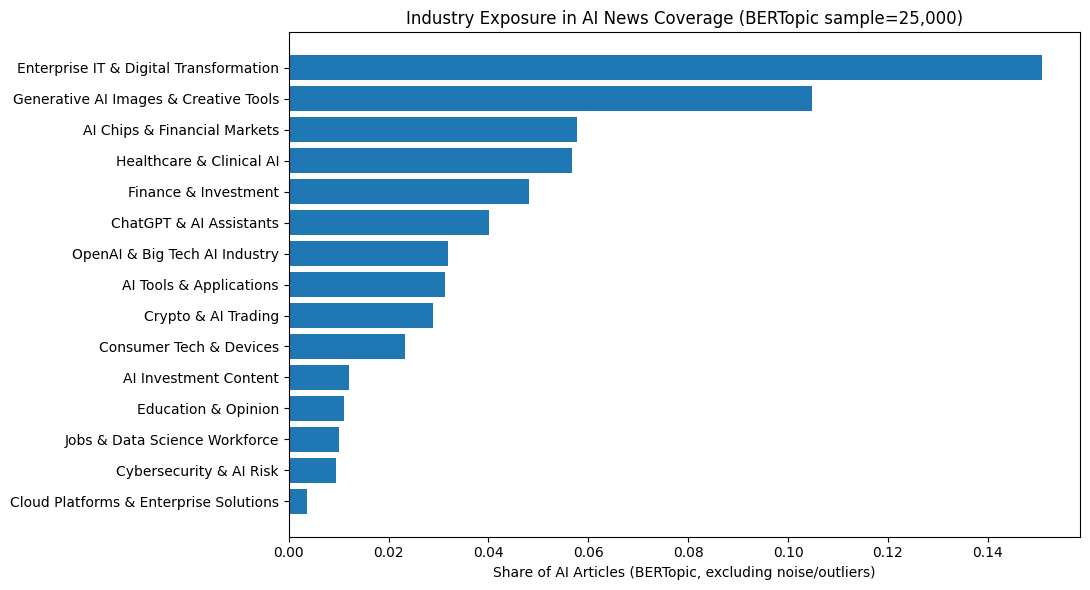

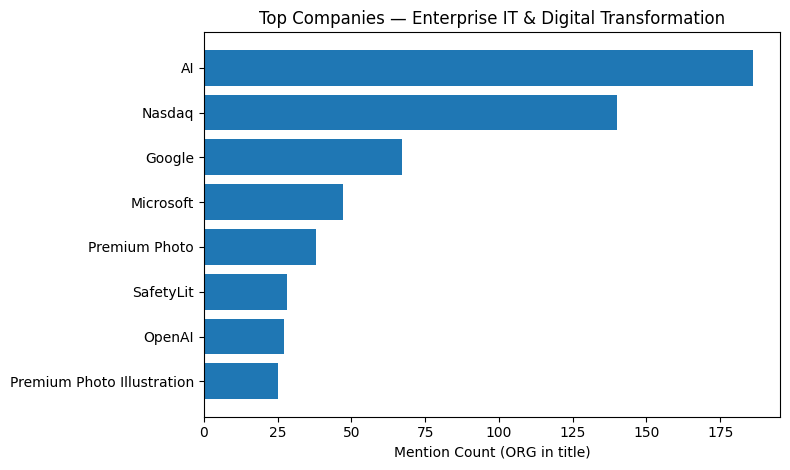

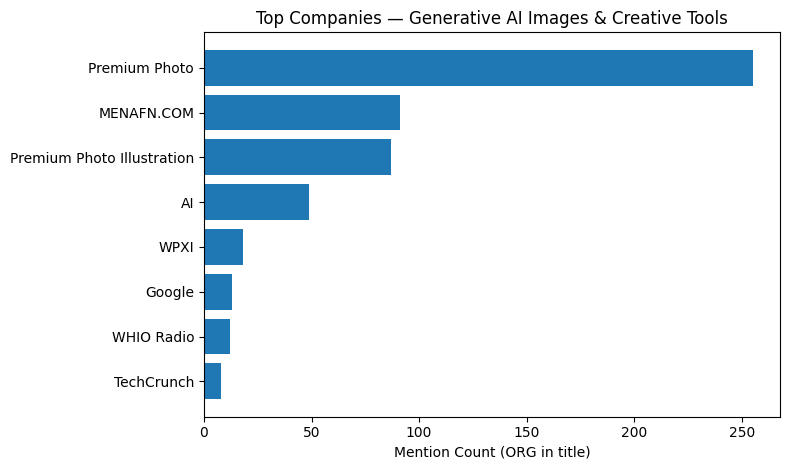

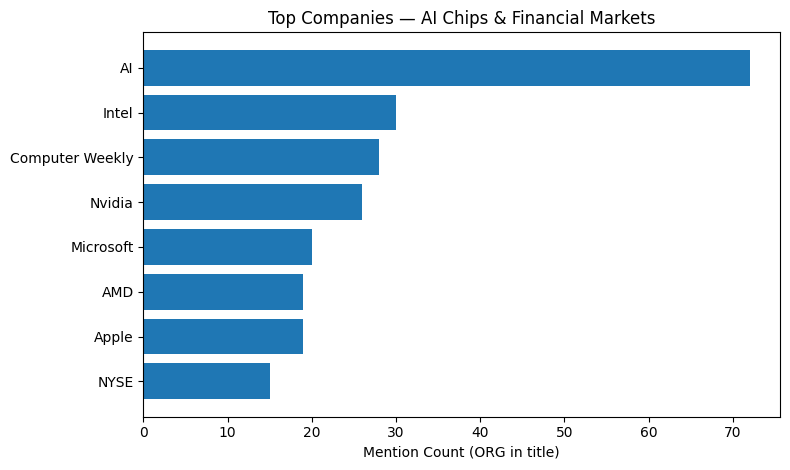

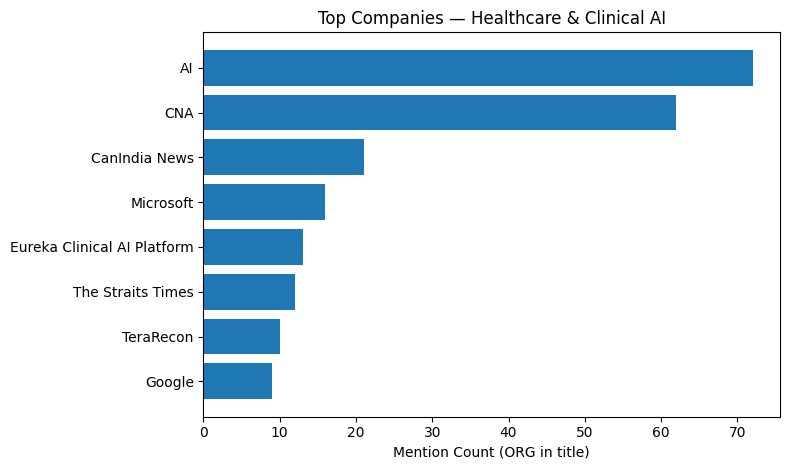

,industry,doc_count,doc_share
1,Enterprise IT & Digital Transformation,2496,0.150916
3,Generative AI Images & Creative Tools,1733,0.104783
4,AI Chips & Financial Markets,956,0.057803
5,Healthcare & Clinical AI,937,0.056654


In [22]:
# 1) BAR GRAPH: Top industries (BERTopic roll-up)
topK_industries = 15  # change if you want

plot_ind = (
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(topK_industries)
    .sort_values("doc_share", ascending=True)
    .copy()
)

plt.figure(figsize=(11, 6))
plt.barh(plot_ind["industry"], plot_ind["doc_share"])
plt.xlabel("Share of AI Articles (BERTopic, excluding noise/outliers)")
plt.title(f"Industry Exposure in AI News Coverage (BERTopic sample={len(df_model):,})")
plt.tight_layout()
plt.show()


# 2) FOUR GRAPHS: Top companies for the top 4 industries

topN_companies = 8      # top companies shown per industry
n_industries_to_plot = 4

top_industries = (
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)["industry"]
    .tolist()
)

for ind in top_industries:
    comp_df = (
        industry_company_table[industry_company_table["industry"] == ind]
        .sort_values("mention_count", ascending=False)
        .head(topN_companies)
        .sort_values("mention_count", ascending=True)
        .copy()
    )

    if comp_df.empty:
        print(f"[WARN] No ORG entities found for industry: {ind}")
        continue

    plt.figure(figsize=(8, 4.8))
    plt.barh(comp_df["company"], comp_df["mention_count"])
    plt.xlabel("Mention Count (ORG in title)")
    plt.title(f"Top Companies — {ind}")
    plt.tight_layout()
    plt.show()



display(
    industry_exposure_focus
    .sort_values("doc_share", ascending=False)
    .head(n_industries_to_plot)[["industry", "doc_count", "doc_share"]]
)